# **Deep Learning with PyTorch**
- **PyTorch** is a python library for building deep learning projects. Its flexible and allows deep learning models to be expressed idiomatic python

  
- **?? Deep learning**
  - **AI** refers to computer systems that are capable of doing tasks that typically require human intelligence
     - Identified class of algorithms capable of approximating complicated, nonlinear processes very, very effectively, which can now be used to automate tasks which were once only limited to humans
       - **Deep learning** is a subcategory of AI that deals with training mathematical entities names `deep neural networks` by presenting instructive examples.

### **The Shift from Machine Learning to Deep Learning**
- Classifical approaches, i.e **_machine learning_** relied heavily on _feature engineering_
- **Raw features**: unmodiefied data values themselves
  - these raw features do not expose the patterns necessary for ml algorithms to perform well and that is where _feature engineering_ comes in.
  - **Feature engineering**: process of using domain knowledge to create new features from raw data in order to make an ml algorithm work more effectively.
    - it involves performing certain transformations (**manually**) that makes it suitable for algorithms to perform as task.
- Deep learning, on the other hand deals with finding these representations _automatically_ from raw data to successfully perform a task.
  - This is done through iterative training while looking at pairs of examples and target labels
  - DL practioners focus on operating on a _mathematical entity_ so that the neural network discovers these representations from the training data autonomously
  - No handcrafting of these representations, because the automatically generated features are comparably better.                           

### **How PyTorch works**
- Rich APIs that helps get the work donw
- Move computations to and from CPU to GPU to computations.
- PyTorch provides tensors the ability to remember numerical operations performed on them by creating history of these operations
  - History: PyTorch can calculate how the final model output will change if we modify any of the initial data.
    - This is used in _numerical optimization_ (i.e how the model learns)
    - And PyTorch's _automatic differentiation_ `autograd` that handles these calculations behind the scenes
      - So, PyTorch's `autograd` helps track operations on tensors, build dynamic computational graphs, and compute gradients via _backpropagation_
     

**Schematic Diagram**</br>
`Data`  -->  `sample tensors`  -->  `untrained model`  -->  `trained model`  -->  `production`


**A few modules in PyTorch**
- `torch.nn`: provides common neural network layers and other architectural components.
  - fully connected layers, convolutional layers, activation functions, and loss functions.
  - These components are used to build and initialize an untrained model
  - To **train a model**
    - a source of training data
    - an optimizer to adapt model to the training data
    - a way to get the model and data to hardware for computations
- `torch.utils.data`: helps with data preparation on the fly.
  - getting data, converting to tensors.
    - basically bridging the custom data (in its default format) and a standardized PyTorch tensor.
`DataLoader class`: gives us the means of efficiently loading and organizing data into _batches_ (i.e tensors containing multiple samples.). We need multiple processes for this kind of task.
- Once the data is ready, a regular python `for loop` is used to create a training loop
  - Model's output is compared to the desired outputs using some kind of _loss function_
- `autograd` and `torch.optim` comes in to help us push the model a bit to better match its outputs to the target.
- A **trained model** is a model whose _parameters_ have been optimized on our task. This model is then deployed into production 

In [1]:
import sys
import torch
 
print(sys.version)                      # prints python version
print(torch.cuda.is_available())        # checks if cuda gpu is available
print(torch.__file__)                   # prints location of torch library

3.12.3 (main, Jun 19 2026, 12:46:00) [GCC 13.3.0]
False
/home/kalamix/dsX/lib/python3.12/site-packages/torch/__init__.py


## **Pretrained Networks**
A very powerful arsenal in deep learning. A pretrained model is especially useful if it has been trained on a large dataset.

Example task of four pretrained networks
- Label an image according to its content
- Fabricate a new image from a real one
- Describe the content of an image
- A model that can finish your sentence

### **A pretrained network that recognizes the subject of an image**
- Run a state-of-the-art deep neural network that was pretrained for object-recognition task
- These models comes with their preoptimized weights, eliminating the need to train from scratch

#### **ImageNet**
- Very large dataset of over 14 million images maintained by Stanford University. Images are labeled with a hierarchy of nouns from the WordNet (a lexical database for English) dataset from Princeton
- Images originated from academic competitions like the ImageNet Large Scale Visual Recognition Challenge; _ILSVRC_
  - **ILSVRC** consists of 1.2 million labeled images with one of 1000 nouns, referred to as the _class_ of the image.
  - Pass your image through the pretrained model, and it outputs a list of predicted labels for that image


**Getting the Pretrained Network**
- The TorchVision Project contains famous neural network architectures from computer vision such as `AlexNet`, `Inception v3` and most recently `VisionTransformer`. 

#### **AlexNet**
- Predefined models can be found in `torchvision.models`
- AlexNet re-ignited the field of deep learning and brought the community into a realization of deep learning for vision tasks.

In [2]:
import torchvision
from torchvision import models

In [4]:
# take a look at the models
models.list_models()

['alexnet',
 'convnext_base',
 'convnext_large',
 'convnext_small',
 'convnext_tiny',
 'deeplabv3_mobilenet_v3_large',
 'deeplabv3_resnet101',
 'deeplabv3_resnet50',
 'densenet121',
 'densenet161',
 'densenet169',
 'densenet201',
 'efficientnet_b0',
 'efficientnet_b1',
 'efficientnet_b2',
 'efficientnet_b3',
 'efficientnet_b4',
 'efficientnet_b5',
 'efficientnet_b6',
 'efficientnet_b7',
 'efficientnet_v2_l',
 'efficientnet_v2_m',
 'efficientnet_v2_s',
 'fasterrcnn_mobilenet_v3_large_320_fpn',
 'fasterrcnn_mobilenet_v3_large_fpn',
 'fasterrcnn_resnet50_fpn',
 'fasterrcnn_resnet50_fpn_v2',
 'fcn_resnet101',
 'fcn_resnet50',
 'fcos_resnet50_fpn',
 'googlenet',
 'inception_v3',
 'keypointrcnn_resnet50_fpn',
 'lraspp_mobilenet_v3_large',
 'maskrcnn_resnet50_fpn',
 'maskrcnn_resnet50_fpn_v2',
 'maxvit_t',
 'mc3_18',
 'mnasnet0_5',
 'mnasnet0_75',
 'mnasnet1_0',
 'mnasnet1_3',
 'mobilenet_v2',
 'mobilenet_v3_large',
 'mobilenet_v3_small',
 'mvit_v1_b',
 'mvit_v2_s',
 'quantized_googlenet',
 '

- All these names are Python classes that implement a number of popular models
- They differ in their _architecture_
  - Architecture being the arrangement of the operations occuring between input and output

In [16]:
# Running alexnet
alexnet = models.AlexNet()

`alexnet` is an instance of the class `AlexNet`. We will use this object to run a forward pass on an image
- **Forward pass**: input --> first set of neurons --> to the next -->--> all the way to the final output. To run a forward pass
  - Unitialized: the network cannot do anything. Uninitialized means the **weights** that the inputs will be added to and multiplied with have not been trained on anything.
    - We need to train the network from scratch or load weights from prior training.

#### **Vision Transformer**
- Uses self-attention mechanisms to improve classification accuracy

Load a `ViT` with its weights for the next task.

In [17]:
vit = models.vit_b_16(weights=models.ViT_B_16_Weights.IMAGENET1K_V1)

Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /home/kalamix/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 330M/330M [01:03<00:00, 5.44MB/s]


In [18]:
vit

VisionTransformer(
  (conv_proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
  (encoder): Encoder(
    (dropout): Dropout(p=0.0, inplace=False)
    (layers): Sequential(
      (encoder_layer_0): EncoderBlock(
        (ln_1): LayerNorm((768,), eps=1e-06, elementwise_affine=True, bias=True)
        (self_attention): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
        )
        (dropout): Dropout(p=0.0, inplace=False)
        (ln_2): LayerNorm((768,), eps=1e-06, elementwise_affine=True, bias=True)
        (mlp): MLPBlock(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU(approximate='none')
          (2): Dropout(p=0.0, inplace=False)
          (3): Linear(in_features=3072, out_features=768, bias=True)
          (4): Dropout(p=0.0, inplace=False)
        )
      )
      (encoder_layer_1): EncoderBlock(
        (ln_1): LayerNorm((768,), eps=1e-06, elementwise_affine

- Each line is a module otherwise called layers; these are the building blocks of neural networks
- Larget building blocks (e.g Encoder) contains submodules which in turn holds other modules

**Neural Network Anatomy**:  a sequential cascade of operations and nonlinear functions ending with a layer producing scores of each output class (features)

In [19]:
# preprocessing input using torchvision's transforms for quick basic preprocessing
from torchvision import transforms

preprocess = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

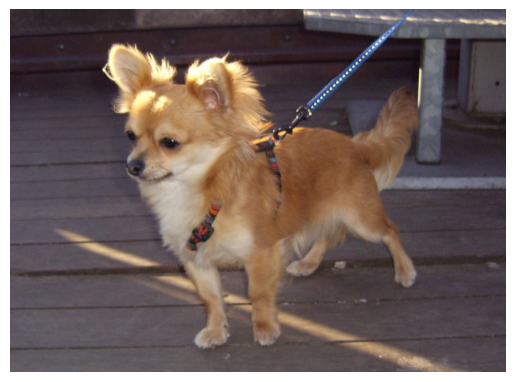

In [26]:
# load image
from PIL import Image

img = Image.open("/home/kalamix/Downloads/Bobby.jpeg")
# img.show()
plt.imshow(img)
plt.axis("off")
plt.show()

In [30]:
# preprocess image
img_t = preprocess(img)

In [31]:
import torch
batch_t = torch.unsqueeze(img_t, 0)

In [34]:
print(img_t.shape)
print(batch_t.shape)

torch.Size([3, 224, 224])
torch.Size([1, 3, 224, 224])


`torch.unsqueeze` adds a new dimension of size 1 at a specified index. 
- In this case, at the very beginning, index 0


**Inference:** Running a pretrained model on a new data. Inference is done in the `eval()` mode
- Eval mode makes internal sections of the model like _batch normalization_ and _dropout_ produce meaningful output otherwise not, just because of the way they work internally.

In [35]:
# run the model
vit.eval()

VisionTransformer(
  (conv_proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
  (encoder): Encoder(
    (dropout): Dropout(p=0.0, inplace=False)
    (layers): Sequential(
      (encoder_layer_0): EncoderBlock(
        (ln_1): LayerNorm((768,), eps=1e-06, elementwise_affine=True, bias=True)
        (self_attention): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
        )
        (dropout): Dropout(p=0.0, inplace=False)
        (ln_2): LayerNorm((768,), eps=1e-06, elementwise_affine=True, bias=True)
        (mlp): MLPBlock(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU(approximate='none')
          (2): Dropout(p=0.0, inplace=False)
          (3): Linear(in_features=3072, out_features=768, bias=True)
          (4): Dropout(p=0.0, inplace=False)
        )
      )
      (encoder_layer_1): EncoderBlock(
        (ln_1): LayerNorm((768,), eps=1e-06, elementwise_affine

In [36]:
out = vit(batch_t)
out

tensor([[-2.7943e-01, -1.1343e-01,  1.1937e-01,  1.9181e-01,  3.9862e-01,
         -1.0744e-01,  4.8552e-01,  4.2494e-01,  7.3945e-01, -4.6550e-01,
         -5.5918e-01,  1.1419e-01,  1.1733e-02, -2.0158e-01,  2.4956e-01,
         -1.1049e-01,  9.2336e-02,  8.2572e-02,  1.4506e-01, -2.3286e-03,
          1.9023e-01,  2.9081e-02,  1.5748e-01, -2.1889e-02,  1.6307e-01,
          1.3616e-01,  3.0023e-02, -4.3098e-01, -1.3871e-01,  1.4487e-01,
          3.3790e-03, -2.3507e-01, -8.1731e-02,  1.3550e-02,  3.9590e-01,
          4.5611e-01, -2.0303e-01, -5.9105e-01,  1.0716e-01, -1.0610e-01,
         -5.1900e-01,  1.8698e-02, -5.8563e-01,  2.0506e-01,  4.9987e-01,
         -1.5217e-01,  2.1665e-01,  6.4907e-02,  1.6547e-01,  6.4190e-03,
          2.9439e-01, -3.8494e-01,  2.6758e-01,  2.5109e-01, -1.9851e-01,
          4.5024e-02, -1.1645e-01, -2.2716e-02,  4.6991e-02, -1.9062e-01,
          3.0878e-01, -6.5840e-01,  4.5539e-01, -4.0222e-01, -7.4229e-02,
          7.9800e-02, -3.9288e-01,  8.

In [39]:
with open("/home/kalamix/Documents/Mphil/Code/gitHubRepos/dlwpt-code-2e/data/p1ch2/imagenet_classes.txt") as f:
    labels = [f.strip() for f in f.readlines()]

In [41]:
_, index = torch.max(out, 1)

In [42]:
percentage = torch.nn.functional.softmax(out, dim=1)[0] * 100
labels[index.item()], percentage[index.item()].item()

('Chihuahua', 82.9107666015625)

## Tensors
- Deep learning involves building a system that can transform data from one representation to another.
  - conversion of input into floating-point numbers
 
**Floating point numbers** are the way a network deals with information
- Encode real-world data of the kind we wanna process into something digestible by a network
- Decode the output back so something we can understand and use for our purpose
- DNN learns the transformation from one form of data to another in stages
  - partially transformed data between each stage = sequence of intermediate transformations
  - intermediate transformations are the results of combining input with the weights of the previews layer of neurons, making each intermediate representation unique to the inputs that preceeded it

**Tensors** refer to the generalization of vectors and matrices to an arbitrary number of dimensions; also referred to as a _multidimensional array_
- zero-indexed, ordered from left to right etc

In [10]:
# python list
a = [1.0, 2.0, 3.0]
a[0]

1.0

In [16]:
# creating a tensor

import torch

a = torch.ones(3)
a

tensor([1., 1., 1.])

In [17]:
a[1]

tensor(1.)

In [18]:
float(a[1])

1.0

In [21]:
# assigning a new value to an element in a tensor
a[2] = 2.0

In [22]:
a

tensor([1., 1., 2.])

In [39]:
# storing coordiinates of the vertices of a triangle
# initialize a one-dimensional tensor with zeros
points = torch.zeros(6)
points[0] = 4.0
points[1] = 1.0
points[2] = 5.0
points[3] = 3.0
points[4] = 2.0
points[5] = 1.0

points

tensor([4., 1., 5., 3., 2., 1.])

In [40]:
# can also pass as a python list
points = torch.tensor([4.0, 1.0, 5.0, 3.0, 2.0, 1.0])
points

tensor([4., 1., 5., 3., 2., 1.])

In [43]:
# get coordinates from tensor
float(points[0]), float(points[1])

(4.0, 1.0)

In [46]:
# a more ideal setup where first index is 2D points
# using a 2D tensor for this

points = torch.tensor([[4.0, 1.0],
                       [5.0, 3.0],
                       [2.0, 1.0]])
points.shape

torch.Size([3, 2])

In [47]:
# initialize a 2D tensor with zeros or ones
points = torch.zeros(3, 2)
points

tensor([[0., 0.],
        [0., 0.],
        [0., 0.]])

In [49]:
points = torch.ones([3, 2])
points

tensor([[1., 1.],
        [1., 1.],
        [1., 1.]])

In [52]:
# accessing elements
points = torch.tensor([[4.0, 1.0],
                       [5.0, 3.0],
                       [2.0, 1.0]])

# [r, c]
points[0, 1]  # returns the second element of the first row

tensor(1.)

In [53]:
# return coordinates
points[0]

tensor([4., 1.])

In [64]:
# indexing tensors
some_list = list(range(6))
print(some_list[:])      # all elements in the tensor
print(some_list[1:4])    # from element one inclusive and 4 exclusive
print(some_list[1:])     # from element one to the end of list
print(some_list[:4])     # from element 0 or first item to element 4 exclusive
print(some_list[:-1])    # from first element to item before the last
print(some_list[1:4:2])  # from element 1 inclusive to element 4 exclusive, in steps of 2

print(points[:])
print(points[1:, :])
print(points[None])       # adds one dimension of size 1, same as points.unsqueeze(dim=0)
print(points.unsqueeze(dim=0))

[0, 1, 2, 3, 4, 5]
[1, 2, 3]
[1, 2, 3, 4, 5]
[0, 1, 2, 3]
[0, 1, 2, 3, 4]
[1, 3]
tensor([[4., 1.],
        [5., 3.],
        [2., 1.]])
tensor([[5., 3.],
        [2., 1.]])
tensor([[[4., 1.],
         [5., 3.],
         [2., 1.]]])
tensor([[[4., 1.],
         [5., 3.],
         [2., 1.]]])


In [ ]:
# Broadcasting
